# Logistic Regression

In [7]:
import pandas as pd

df = pd.read_csv("euromillions.csv")

numcols = ["num_1", "num_2", "num_3", "num_4", "num_5"]

rows = []

for index, draw in df.iterrows():
    drawn_nums = set(draw[numcols])
    
    drawn_date = pd.to_datetime(draw["date (dd-mm-yyyy)"], format="%d-%m-%Y")
    
    for num in range (1,51):
        rows.append({"year": drawn_date.year, "month": drawn_date.month, "lotto_number": num, "appeared": 1 if num in drawn_nums else 0})
model_df = pd.DataFrame(rows)

In [8]:
print(len(rows))

96950


In [8]:
model_df.head()

,year,month,lotto_number,appeared
0,2004,2,1,0
1,2004,2,2,0
2,2004,2,3,0
3,2004,2,4,0
4,2004,2,5,0


In [9]:
from sklearn.model_selection import train_test_split

X = model_df[['year', 'month', 'lotto_number']]
y = model_df["appeared"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [11]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.49071686436307377
              precision    recall  f1-score   support

           0       0.90      0.49      0.63     17452
           1       0.10      0.50      0.16      1938

    accuracy                           0.49     19390
   macro avg       0.50      0.49      0.40     19390
weighted avg       0.82      0.49      0.59     19390



In [12]:
from sklearn.metrics import roc_auc_score

y_probs = model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_probs))

ROC-AUC: 0.4917857401353487


In [16]:
future_nums = pd.DataFrame({"year": [2026]*50, "month": [4]*50, "lotto_number": range(1,51)})

future_nums["probability"] = model.predict_proba(future_nums)[:,1]

print(future_nums.sort_values("probability", ascending=False).head(10))

    year  month  lotto_number  probability
49  2026      4            50     0.502008
48  2026      4            49     0.501902
47  2026      4            48     0.501796
46  2026      4            47     0.501690
45  2026      4            46     0.501584
44  2026      4            45     0.501478
43  2026      4            44     0.501372
42  2026      4            43     0.501266
41  2026      4            42     0.501160
40  2026      4            41     0.501054


All numbers aren't even treated equally, bigger numbers are counted as bigger values. Redo with equally valued numbers.

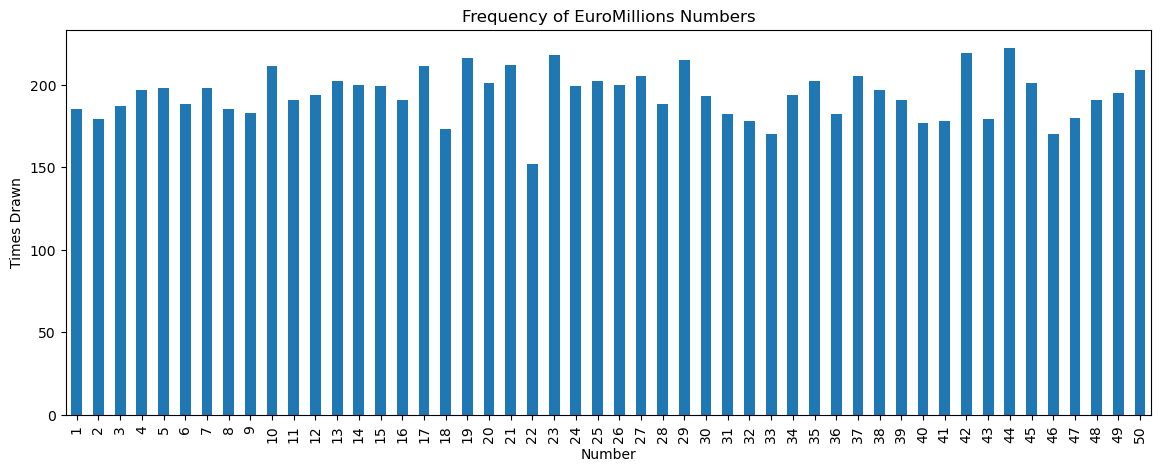

In [31]:
import matplotlib.pyplot as plt

freq = pd.concat([df[col] for col in numcols]).value_counts().sort_index()

freq.plot(kind='bar', figsize=(14,5))
plt.title("Frequency of EuroMillions Numbers")
plt.xlabel("Number")
plt.ylabel("Times Drawn")
plt.show()

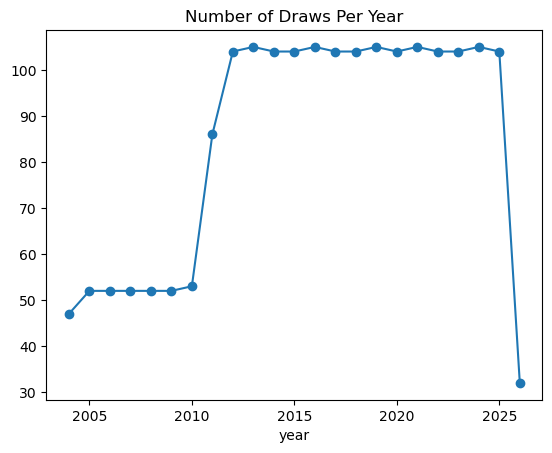

In [35]:
df["year"] = pd.to_datetime(df["date (dd-mm-yyyy)"], format="%d-%m-%Y").dt.year

yearly_counts = df.groupby("year").size()

yearly_counts.plot(marker='o')
plt.title("Number of Draws Per Year")
plt.show()

In [18]:
pd.get_dummies(model_df["lotto_number"])

,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96945,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
96946,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
96947,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
96948,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [20]:
dummynum = pd.get_dummies(model_df["lotto_number"], prefix='num')

In [27]:
X = dummynum

In [28]:
y = model_df["appeared"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [31]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

In [32]:
coef_df = coef_df.sort_values(
    "coefficient",
    ascending=False
)

print(coef_df.head(10))   # strongest positive effects
print(coef_df.tail(10))   # strongest negative effects

   feature  coefficient
18  num_19     0.149093
16  num_17     0.140770
43  num_44     0.137284
28  num_29     0.135403
22  num_23     0.135310
49  num_50     0.131089
41  num_42     0.101986
34  num_35     0.095383
9   num_10     0.074106
20  num_21     0.067279
   feature  coefficient
35  num_36    -0.069553
7    num_8    -0.084848
8    num_9    -0.090680
31  num_32    -0.096805
39  num_40    -0.108083
17  num_18    -0.117088
42  num_43    -0.127941
32  num_33    -0.128100
30  num_31    -0.171475
21  num_22    -0.229476
